# Introduction to Mathematical Modelling

**by Dr Kamil Erguler**  
Climate and One Health Group  
CARE-C - The Cyprus Institute

---

[Previous (Regression)](https://veclim.com/tutorials-viewer/localfile/MathMod/T03_IMM_regression.ipynb) --- [Index](https://veclim.com/tutorials-viewer/localfile/MathMod/T00_IMM_intro.ipynb) --- [Next (Approximate Bayesian Computation)](https://veclim.com/tutorials-viewer/localfile/MathMod/T05_IMM_ABC.ipynb)


## Thermal performance curves — Part 2

Let us roll up our sleeves, request some additional funding, and seek an extension to the project so that we can conduct a few more experiments and observe the behaviour of *E. coli* over a broader temperature range. Fortunately for us, <a href="https://doi.org/10.1371/journal.pone.0153343" target="_blank" rel="noopener noreferrer"><strong>Corkrey</strong></a> and colleagues have already compiled an extensive dataset, giving us plenty more to explore.

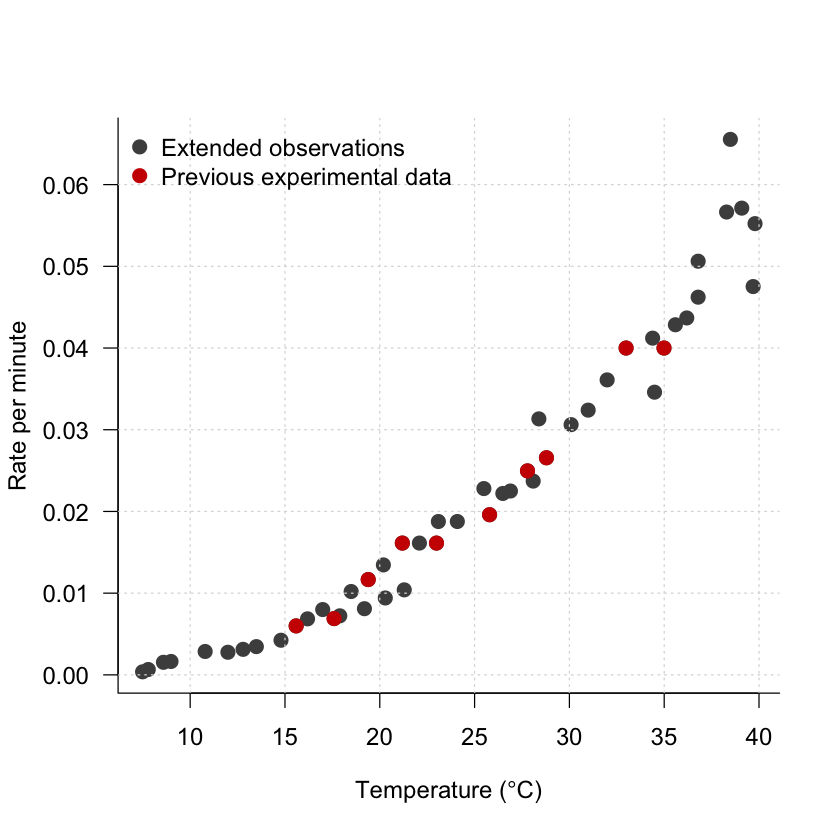

In [1]:
# S1 Data - Corkrey R, McMeekin TA, Bowman JP, Ratkowsky DA, Olley J, Ross T (2016) 
# The Biokinetic Spectrum for Temperature. PLoS ONE 11(4): e0153343. 
# https://doi.org/10.1371/journal.pone.0153343

Corkrey <- read.csv("https://doi.org/10.1371/journal.pone.0153343.s004")

d <- Corkrey[
  (Corkrey$binomial.name == "Escherichia coli") &
    (Corkrey$strain.code == 547) &
    (Corkrey$T.C >= 15) &
    (Corkrey$T.C <= 35),
]
d <- d[order(d$T.C), ]
d <- d[round(seq(1, nrow(d), length.out = 10)), ]

d2 <- Corkrey[
  (Corkrey$binomial.name == "Escherichia coli") &
    (Corkrey$strain.code == 547) &
    (Corkrey$T.C <= 40),
]
d2 <- d2[order(d2$T.C), ]

par(bg = "white", cex = 1.2)

cols <- c("d2" = "grey30", "d" = "red3")

plot(d2$T.C, d2$rate.per.minute,
  type = "p", pch = 16, cex = 1.4,
  col = cols["d2"], las = 1, bty = "l",
  xlab = expression("Temperature ("*degree*C*")"),
  ylab = "Rate per minute",
  xlim = range(c(d2$T.C, d$T.C), na.rm = TRUE),
  ylim = range(c(d2$rate.per.minute, d$rate.per.minute), na.rm = TRUE))

grid(col = "grey85", lty = "dotted")

points(d$T.C, d$rate.per.minute, type = "p", pch = 16, cex = 1.4, col = cols["d"])

legend("topleft",
  legend = c("Extended observations", "Previous experimental data"),
  col = cols, pch = 16, pt.cex = 1.4, bty = "n")

Here, we extend the temperature range to below $10^{\circ}C$ and up to $40^{\circ}C$, revealing a distinctly non-linear trend. At lower temperatures, the new observations curve more strongly towards zero without crossing it — as we might expect, since a growth rate cannot become negative.

What might happen at extremely high temperatures? Would the growth rate continue to increase linearly beyond $40^{\circ}C$? Would it increase exponentially, stabilise, or eventually decline?

Let us formalise some of these possibilities as competing hypotheses:

* **The linear (positive) model**

$
\rho_1(T)=aT+b+\epsilon.
$

* **The exponential model**

$
\rho_2(T)=a\,e^{b(T-c)}+\epsilon.
$

* **The Brière model**

$
\rho_3(T) = aT(T-b)
\sqrt{c-T}
+\epsilon,
\qquad
b<T<c,
$

with the expected growth rate set to zero outside this interval.

In every model, we assume that

$
\epsilon\sim\mathcal N(0,\sigma^2),
$

and, for now, we will simply overlook the occasional negative values this may produce — especially when growth rates are low and variation is high.


---

The Brière model is new to our collection. It was originally introduced by <a href="https://doi.org/10.1093/ee/28.1.22" target="_blank" rel="noopener noreferrer"><strong>Brière</strong></a> and colleagues to describe temperature-dependent development rates in arthropods. Despite its origins, its shape provides a useful phenomenological description of a more general thermal performance curve.

The parameters $b$ and $c$ represent the lower and upper thermal limits. Between these limits, performance initially increases with temperature, reaches an optimum, and then falls more sharply towards zero as $T$ approaches $c$. Unlike the linear and exponential models, the Brière model therefore allows high temperatures to become detrimental rather than assuming that performance will increase indefinitely.

In [2]:
models <- list()

models[["linear"]] <- list(
  "sim.mean" = function(T, param) {
    pr_a <- param[1]
    pr_b <- param[2]
    return(pr_a * T + pr_b)
  }
)

models[["exponential"]] <- list(
  "sim.mean" = function(T, param) {
    pr_a <- param[1]
    pr_b <- param[2]
    pr_c <- param[3]
    return(pr_a * exp(pr_b * (T - pr_c)))
  }
)

models[["briere"]] <- list(
  "sim.mean" = function(T, param) {
    pr_a <- param[1]
    pr_b <- param[2]  # lower thermal limit
    pr_c <- param[3]  # upper thermal limit

    rho <- numeric(length(T))

    inside <- T > pr_b & T < pr_c
    rho[inside] <- pr_a * T[inside] * (T[inside] - pr_b) * sqrt(pr_c - T[inside])

    return(rho)
  }
)

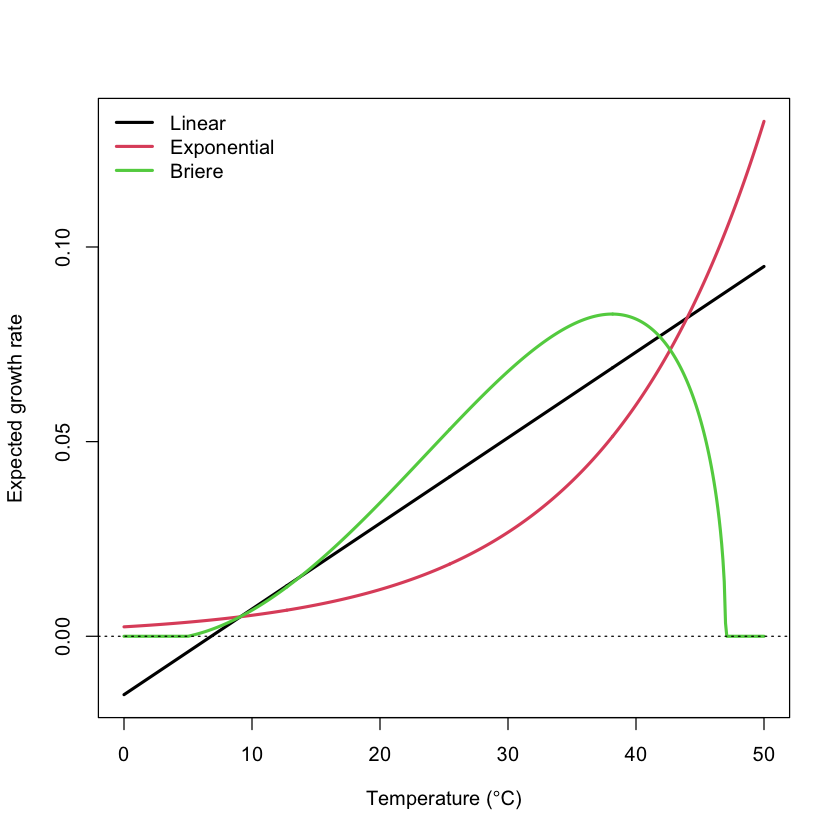

In [3]:
# Temperature range used only for illustration
T_grid <- seq(0, 50, length.out = 500)

# Illustrative parameter configurations
parameters <- list(
  linear      = c(pr_a = 0.0022, pr_b = -0.015),
  exponential = c(pr_a = 0.012, pr_b = 0.08, pr_c = 20),
  briere      = c(pr_a = 2.2e-5, pr_b = 5, pr_c = 47)
)

# Calculate the expected response under each model
predictions <- sapply(names(models), function(model_name) {
    models[[model_name]]$sim.mean(T_grid, parameters[[model_name]])
  })

colnames(predictions) <- c("Linear", "Exponential", "Briere")

# Plot
par(bg = "white")

matplot(T_grid, predictions,
  type = "l", lty = 1, lwd = 2.5, ylim = range(c(0, predictions), finite = TRUE),
  xlab = expression("Temperature (" * degree * "C)"), ylab = "Expected growth rate")

abline(h = 0, lty = 3)

legend("topleft",
  legend = colnames(predictions), col = seq_len(ncol(predictions)),
  lty = 1, lwd = 2.5, bty = "n")

One way to work out which model best explains the data is to run a separate Metropolis–Hastings sampler for each one and then compare the fitted models. 

A more direct alternative is to let them compete in the same multi-model inference race. To do this, we will treat the model itself as an unknown quantity and estimate both

$
M,
$

the model underlying the observations, and

$
\theta_M,
$

the parameters belonging to that model.

Because the models may have different parameters — and even different numbers of parameters — we need a sampler that can explore both model space and parameter space.


## Model and Parameter Selection

When we fitted a single model using Metropolis–Hastings, the unknown state consisted only of its parameters: $\theta$.

Here, each state, or **particle**, consists of a model and the parameters belonging to that model: $(M,\theta_M)$.

For example, one possible particle is

$
\left(
M=\text{linear},
\theta_M=(0.0022,-0.015,0.01)
\right).
$

Another is

$
\left(
M=\text{exponential},
\theta_M=(0.012,0.08,-20.0,0.01)
\right).
$

The joint posterior distribution is

$
P(M,\theta_M\mid\delta)
\propto
P(\delta\mid\theta_M,M)
P(\theta_M\mid M)
P(M),
$

where:

* $P(\delta\mid\theta_M,M)$ is the likelihood;
* $P(\theta_M\mid M)$ is the parameter prior for model (M);
* $P(M)$ is the prior probability of model (M).


### A simple rejection sampler

A classic introduction to Monte Carlo methods is to estimate the area of a circle by throwing points randomly at a surrounding square and counting how many land inside the circle. The proportion of points that fall inside the circle allows us to estimate its unknown area from the known area of the square.

Rejection sampling follows a similar idea: we generate random proposals and keep only those that pass a chosen acceptance test.

To generate random proposals, we draw particles from the priors. First, we sample a model from $P(M)$. Then, conditional on that model, we sample its parameters from $P(\theta_M\mid M)$.

Thus, the initial particle population represents

$
P(M)P(\theta_M\mid M),
$

our beliefs before considering the observations.

We then test each particle against the likelihood. For every particle, we calculate the likelihood $P(\delta\mid\theta_M,M)$ and accept or reject the particle according to its value.

Let $L_{\max}$ be a valid upper bound on the likelihood. The particle can then be accepted with probability

$
\alpha = \frac{
P(\delta\mid\theta_M,M)
}{
L_{\max}
}.
$

The upper bound ensures that $\alpha$ lies between 0 and 1 and can therefore be interpreted as an acceptance probability. Remember that, for continuous observations, the likelihood is a probability density and may be greater than 1. Dividing by $L_{\max}$ rescales it while preserving the relative support for different particles. The bound need not be tight, although choosing it much larger than necessary will lead to many rejections.

Particles that explain the observations well are therefore more likely to survive, while poorly supported particles are usually rejected. The accepted particles represent samples from the joint posterior distribution.

In [4]:
# Let's add prior samplers and likelihood evaluators to each model

# The linear model
models[["linear"]]$sample.prior <- function() {
    c(pr_a = runif(1, 0, 0.005),
      pr_b = runif(1, -0.10, 0.10),
      sigma = runif(1, 0.002, 0.05))
}

models[["linear"]]$log.likelihood <- function(T, rho, param) {
    expected <- models[["linear"]]$sim.mean(T, param)
    sum(dnorm(rho, mean = expected, sd = param["sigma"], log = TRUE))
}

# The exponential model
models[["exponential"]]$sample.prior <- function() {
    c(pr_a = runif(1, 0, 0.10),
      pr_b = runif(1, -0.10, 0.20),
      pr_c = runif(1, 0, 30),
      sigma = runif(1, 0.002, 0.05))
}

models[["exponential"]]$log.likelihood <- function(T, rho, param) {
    expected <- models[["exponential"]]$sim.mean(T, param)
    sum(dnorm(rho, mean = expected, sd = param["sigma"], log = TRUE))
}

# The Briere model
models[["briere"]]$sample.prior <- function() {
    c(pr_a = runif(1, 0, 5e-5),
      pr_b = runif(1, 0, 15),
      pr_c = runif(1, 35, 55),
      sigma = runif(1, 0.002, 0.05))
}

models[["briere"]]$log.likelihood <- function(T, rho, param) {
    expected <- models[["briere"]]$sim.mean(T, param)
    sum(dnorm(rho, mean = expected, sd = param["sigma"], log = TRUE))
}

In [5]:
rejection.sampler <- function(models,
                              T,
                              rho,
                              n_accept = 1000,
                              model_prior = NULL,
                              L_max = 1.0,
                              max_proposals = 1e7,
                              verbose = TRUE) {
  model_names <- names(models)
  n_models <- length(model_names)

  # Equal prior probability unless otherwise specified
  if (is.null(model_prior)) {
    model_prior <- rep(1 / n_models, n_models)
    names(model_prior) <- model_names
  } else {
    model_prior <- model_prior[model_names]
    model_prior <- model_prior / sum(model_prior)
  }

  log_likelihood_max <- log(L_max)

  accepted_models <- character(n_accept)
  accepted_parameters <- vector("list", n_accept)
  accepted_log_likelihoods <- numeric(n_accept)

  all_log_likelihoods <- numeric(max_proposals)

  n_proposed <- 0L
  n_accepted <- 0L

  while (n_accepted < n_accept && n_proposed < max_proposals) {
    n_proposed <- n_proposed + 1L
    
    # Draw a model from the model prior
    model_name <- sample(model_names, size = 1, prob = model_prior)

    model <- models[[model_name]]

    # Draw parameters from the model-specific prior
    param <- model$sample.prior()

    # Evaluate the particle
    log_likelihood <- model$log.likelihood(T, rho, param)

    if (!is.finite(log_likelihood)) { next }

    # Check that the proposed upper bound is valid
    if (log_likelihood > log_likelihood_max) {
      stop("A likelihood exceeded log_likelihood_max. ",
           "The likelihood bound is not valid.")
    }

    # Equivalent to:
    #
    # runif(1) < likelihood / L_max
    #
    # but more numerically stable
    if (log(runif(1)) < log_likelihood - log_likelihood_max) {
      n_accepted <- n_accepted + 1L

      accepted_models[n_accepted] <- model_name
      accepted_parameters[[n_accepted]] <- param
      accepted_log_likelihoods[n_accepted] <- log_likelihood
    }

    all_log_likelihoods[n_proposed] <- log_likelihood

    if (verbose && n_proposed %% 100000 == 0) {
      cat(sprintf("Proposed: %d | Accepted: %d | Rate: %.6f\n", n_proposed, n_accepted, n_accepted / n_proposed))
    }
  }

  # Remove unused preallocated entries
  keep <- seq_len(n_accepted)

  particles <- data.frame(
    model = accepted_models[keep],
    log_likelihood = accepted_log_likelihoods[keep],
    stringsAsFactors = FALSE
  )

  particles$param <- I(accepted_parameters[keep])

  model_probabilities <- prop.table(
    table(factor(particles$model, levels = model_names))
  )

  list(
    particles = particles,
    model_probabilities = setNames(as.numeric(model_probabilities), model_names),
    model_prior = model_prior,
    log_likelihood_max = log_likelihood_max,
    n_proposed = n_proposed,
    n_accepted = n_accepted,
    acceptance_rate = n_accepted / n_proposed,
    all_log_likelihoods = all_log_likelihoods
  )
}

In [6]:
model_prior <- c(
  linear = 1 / 3,
  exponential = 1 / 3,
  briere = 1 / 3
)

rejection_fit <- rejection.sampler(
  models = models,
  T = d2$T.C,
  rho = d2$rate.per.minute,
  n_accept = 500,
  model_prior = model_prior,
  L_max = 8e89,
  max_proposals = 1e7
)

Proposed: 100000 | Accepted: 0 | Rate: 0.000000
Proposed: 200000 | Accepted: 0 | Rate: 0.000000
Proposed: 300000 | Accepted: 0 | Rate: 0.000000
Proposed: 400000 | Accepted: 0 | Rate: 0.000000
Proposed: 500000 | Accepted: 0 | Rate: 0.000000
Proposed: 600000 | Accepted: 0 | Rate: 0.000000
Proposed: 700000 | Accepted: 0 | Rate: 0.000000
Proposed: 800000 | Accepted: 0 | Rate: 0.000000
Proposed: 900000 | Accepted: 0 | Rate: 0.000000
Proposed: 1000000 | Accepted: 0 | Rate: 0.000000
Proposed: 1100000 | Accepted: 0 | Rate: 0.000000
Proposed: 1200000 | Accepted: 0 | Rate: 0.000000
Proposed: 1300000 | Accepted: 0 | Rate: 0.000000
Proposed: 1400000 | Accepted: 0 | Rate: 0.000000
Proposed: 1500000 | Accepted: 0 | Rate: 0.000000
Proposed: 1600000 | Accepted: 0 | Rate: 0.000000
Proposed: 1700000 | Accepted: 0 | Rate: 0.000000
Proposed: 1800000 | Accepted: 0 | Rate: 0.000000
Proposed: 1900000 | Accepted: 0 | Rate: 0.000000
Proposed: 2000000 | Accepted: 0 | Rate: 0.000000
Proposed: 2100000 | Accepted:

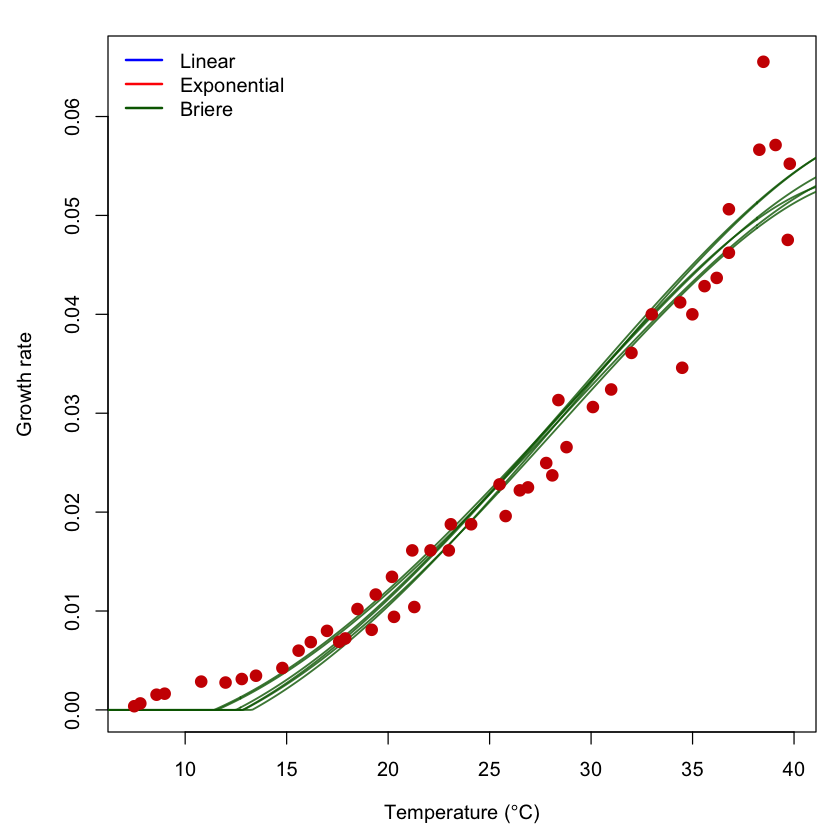

In [7]:
model_colours <- c(
  linear      = "blue",
  exponential = "red",
  briere      = "darkgreen"
)

par(bg = "white", mar = c(4.5, 4.5, 1.5, 1))

plot(d2$T.C, d2$rate.per.minute,
     type = "n", xlab = expression("Temperature (" * degree * "C)"), ylab = "Growth rate")

for (i in seq_len(nrow(rejection_fit$particles))) {
  model_name <- rejection_fit$particles$model[i]
  param <- rejection_fit$particles$param[[i]]

  expected <- models[[model_name]]$sim.mean(T_grid, param)

  lines(T_grid, expected,
        col = adjustcolor(model_colours[model_name], alpha.f=0.8), lwd = 1.5)
}

# Draw observations on top of the fitted curves
points(d2$T.C, d2$rate.per.minute,
       pch = 16, cex = 1.4, col = cols["d"])

legend("topleft",
  legend = c("Linear", "Exponential", "Briere"),
  col = model_colours, lty = 1, lwd = 2, bty = "n")

Although the rejection sampler does not explicitly penalise models for having more parameters, it still accounts for both the number of parameters and their prior ranges. For each model, particles are drawn across its full prior parameter space, and the model is rewarded only when a substantial share of those particles explains the observations well. 

A model with broad prior ranges, or with many parameters that must fall within a narrow combination of values, will produce many poorly supported particles and few accepted ones. In this way, the comparison is based not only on the best-fitting parameter values, but on how well each model performs on average across its prior parameter space.

This means that prior ranges should be chosen just as carefully as model structures, since excessively broad or narrow priors can strongly affect the resulting model probabilities.

This approach is simple, but it can be extremely inefficient. If the likelihood is concentrated within only a small part of the model–parameter space, most particles drawn from the priors will be rejected. It is rather like waiting for a room full of monkeys, randomly striking typewriter keys, to produce a passage from Shakespeare: success is possible, but almost all attempts will be nowhere close. In our attempt above, 10 million proposals produced fewer than 10 accepted particles.

More advanced approaches, such as sequential Monte Carlo, guide a population of particles gradually from the prior towards the posterior.


### Sequential Monte Carlo (SMC)

Rather than exposing particles drawn from the prior to the full likelihood all at once, we can introduce the likelihood gradually by defining a sequence of intermediate distributions:

$
\pi_\beta(M,\theta_M)
\propto
P(M)
P(\theta_M\mid M)
P(\delta\mid\theta_M,M)^\beta,
$

where

$
0\leq\beta\leq1.
$

At $\beta=0$, the likelihood is raised to the power zero, so

$
\pi_0(M,\theta_M)
\propto
P(M)P(\theta_M\mid M).
$

This is the joint prior.

At $\beta=1$, we obtain

$
\pi_1(M,\theta_M)
\propto
P(M)
P(\theta_M\mid M)
P(\delta\mid\theta_M,M),
$

which is the joint posterior.

We can therefore generate a population of particles and, by repeatedly resampling and perturbing them, gradually move the population through a sequence such as

$
0=\beta_0<\beta_1<\beta_2<\cdots<\beta_S=1.
$

This procedure is known as **likelihood tempering**.


### Resampling the particles

Suppose we have a population of particles representing the intermediate distribution $\pi_{s-1}(M,\theta_M)$ at $\beta_{s-1}$, and we wish to move to the next distribution, $\pi_s(M,\theta_M)$ at $\beta_s$.

Some of the particles would contribute more to the next distribution, and therefore should be kept. We can perhaps more easily let go of the particles not contributing much.

To quantify this, we weight each particle according to the change between these two successive target distributions. The incremental weight of particle $i$ is therefore

$
\widetilde w_i = \frac{
\pi_s(M_i,\theta_i)
}{
\pi_{s-1}(M_i,\theta_i)
}.
$

Because the model and parameter priors appear in both distributions, they cancel, leaving

$
\widetilde w_i = P(\delta\mid\theta_i,M_i)^{\beta_s-\beta_{s-1}}.
$

On the logarithmic scale,

$
\log\widetilde w_i = (\beta_s-\beta_{s-1})
\log P(\delta\mid\theta_i,M_i).
$

Particles with higher likelihoods, and therefore greater support from the observations, receive larger weights and are more likely to be retained in the next population. Particles with lower likelihoods receive smaller weights and are more likely to disappear during resampling.

At this stage, however, no particles have yet been removed. We have only changed how strongly each particle contributes to the current approximation.

---

After weighting, we may find that only a small number of particles carry most of the total weight. For example, a population of 1,000 particles may behave as though it contains only 40 useful particles.

We measure this using the **effective sample size**:

$
\mathrm{ESS} = \frac{1}{
\sum_{i=1}^{N}w_i^2
}.
$

If all weights are equal, $w_i=\frac{1}{N}$, then $\mathrm{ESS}=N$.

If one particle carries nearly all the weight, then $\mathrm{ESS}\approx1$.

At each step, we calculate the ESS and compare it with a chosen threshold. If the ESS falls below this threshold, the particle population has become too unevenly weighted and should be resampled.

We resample the population by selecting particles with probabilities equal to their weights. Well-supported particles are likely to be copied, while poorly supported particles are likely to disappear.

After resampling, all particles again have equal weight and collectively approximate the current intermediate distribution.

However, resampling creates duplicates. Several particles may now contain exactly the same model and parameter values, so we must reintroduce variation into the population.


### Moving the parameters within a model

To maintain variation and allow particles to explore the current intermediate distribution, each particle may be perturbed using a Metropolis–Hastings move.

Suppose the current particle contains model $M$ and parameters $\theta$. We propose

$
\theta'=\theta+\varepsilon,
$

where

$
\varepsilon\sim N(0,\Sigma_M).
$

Because the model does not change during this move, the model-prior term cancels from the Metropolis–Hastings ratio.

For a **symmetric** random-walk proposal, the log acceptance ratio is

$
\log R = \log P(\theta' \mid M) - \log P(\theta \mid M) + \beta_s\left[ \log P(\delta \mid \theta',M) - \log P(\delta \mid \theta,M) \right].
$

The move is accepted when

$
\log U<\log R,
\qquad
U\sim\mathrm{Uniform}(0,1).
$

This step spreads duplicated particles into nearby regions of parameter space while preserving the current tempered distribution.

It is often called a **rejuvenation move**.


### Moving between models

Within-model rejuvenation moves allow a particle to explore different parameter configurations, but they cannot change its model.

We therefore occasionally propose a move between models.

Suppose the current particle is

$
(M,\theta_M).
$

We propose:

1. a new model $M'$ from the model prior;
2. new parameters $\theta_{M'}'$ from the parameter prior of $M'$.

That is,

$
M'\sim P(M'),
$

and

$
\theta_{M'}'
\sim
P(\theta_{M'}'\mid M').
$

This proposal works even when the models have different numbers of parameters. A three-parameter linear particle can therefore propose a four-parameter exponential particle.

Because we propose the model and its parameters from the same distributions used as their priors, the model-prior and parameter-prior terms cancel with the corresponding proposal terms in the acceptance ratio.

The remaining acceptance ratio is

$
R = \left[
\frac{
P(\delta\mid\theta_{M'}',M')
}{
P(\delta\mid\theta_M,M)
}
\right]^{\beta_s}.
$

On the logarithmic scale,

$
\log R = \beta_s
\left[
\log P(\delta\mid\theta_{M'}',M') - \log P(\delta\mid\theta_M,M)
\right].
$

At low values of $\beta_s$, model moves are accepted relatively easily because the observations have only a weak influence.

As $\beta_s$ approaches one, a proposed model and parameter configuration must explain the observations nearly as well as the current particle to be accepted.

In [11]:
# For the rejuvenation moves, we need the log-prior density and proposal scales for each model.

# The linear model
models[["linear"]]$log.prior <- function(param) {
  pr_a <- param["pr_a"]
  pr_b <- param["pr_b"]
  sigma <- param["sigma"]

  if (any(!is.finite(c(pr_a, pr_b, sigma))) ||
      pr_a < 0 || pr_a > 0.005 ||
      pr_b < -0.10 || pr_b > 0.10 ||
      sigma < 0.002 || sigma > 0.05) {
    return(-Inf)
  }

  -log(0.005 - 0) - log(0.10 - (-0.10)) - log(0.05 - 0.002)
}

models[["linear"]]$proposal.sd <- c(pr_a = 0.00015, pr_b = 0.006, sigma = 0.0015)

# The exponential model
models[["exponential"]]$log.prior <- function(param) {
  pr_a <- param["pr_a"]
  pr_b <- param["pr_b"]
  pr_c <- param["pr_c"]
  sigma <- param["sigma"]

  if (any(!is.finite(c(pr_a, pr_b, pr_c, sigma))) ||
      pr_a < 0.0 || pr_a > 0.10 ||
      pr_b < -0.10 || pr_b > 0.20 ||
      pr_c < 0 || pr_c > 30 ||
      sigma < 0.002 || sigma > 0.05) {
    return(-Inf)
  }

  -log(0.10 - 0.0) - log(0.20 - (-0.10)) - log(30 - 0) - log(0.05 - 0.002)
}

models[["exponential"]]$proposal.sd <- c(pr_a = 0.0015, pr_b = 0.005, pr_c = 0.75, sigma = 0.0015)

# The Briere model
models[["briere"]]$log.prior <- function(param) {
  pr_a <- param["pr_a"]
  pr_b <- param["pr_b"]
  pr_c <- param["pr_c"]
  sigma <- param["sigma"]

  if (any(!is.finite(c(pr_a, pr_b, pr_c, sigma))) ||
      pr_a < 0 || pr_a > 5e-5 ||
      pr_b < 0 || pr_b > 15 ||
      pr_c < 35 || pr_c > 55 ||
      sigma < 0.002 || sigma > 0.05) {
    return(-Inf)
  }

  -log(5e-5 - 0) - log(15 - 0) - log(55 - 35) - log(0.05 - 0.002)
}

models[["briere"]]$proposal.sd <- c(pr_a = 1.5e-6, pr_b = 0.5, pr_c = 0.5, sigma = 0.0015)

In [9]:
smc.model.selection <- function(models,
                                T,
                                rho,
                                n_particles = 2000,
                                temperatures = seq(0, 1, length.out = 40)^2,
                                model_prior = NULL,
                                ess_threshold = 0.5,
                                mh_steps = 3,
                                global_move_probability = 0.2) {
  # ----------------------------------------------------------
  # We call the sequence of beta values temperatures.
  # Here, we use a quadratic sequence with smaller steps near zero,
  # introducing the likelihood gently at first before moving more
  # quickly towards the target distribution.
  # ----------------------------------------------------------
  
  model_names <- names(models)
  n_models <- length(model_names)

  # Equal prior probability unless otherwise specified
  if (is.null(model_prior)) {
    model_prior <- rep(1 / n_models, n_models)
    names(model_prior) <- model_names
  } else {
    model_prior <- model_prior[model_names]
    model_prior <- model_prior / sum(model_prior)
  }

  normalise_log_weights <- function(log_weights) {
    largest <- max(log_weights)

    if (!is.finite(largest)) {
      stop("All particle weights are zero.")
    }

    weights <- exp(log_weights - largest)
    weights / sum(weights)
  }

  log_weighted_sum_exp <- function(log_values, weights) {
    largest <- max(log_values)

    if (!is.finite(largest)) {
      return(largest)
    }

    largest + log(sum(weights * exp(log_values - largest)))
  }

  effective_sample_size <- function(weights) {
    1 / sum(weights^2)
  }

  # ----------------------------------------------------------
  # 1. Initialise particles from the joint prior
  # ----------------------------------------------------------

  particle_model <- sample.int(n_models, size = n_particles, replace = TRUE, prob = model_prior)

  particle_theta <- vector("list", n_particles)
  particle_log_prior <- numeric(n_particles)
  particle_log_likelihood <- numeric(n_particles)

  for (i in seq_len(n_particles)) {
    m <- particle_model[i]

    theta <- models[[m]]$sample.prior()

    particle_theta[[i]] <- theta
    particle_log_prior[i] <- models[[m]]$log.prior(theta)
    particle_log_likelihood[i] <- models[[m]]$log.likelihood(T, rho, theta)
  }

  weights <- rep(1 / n_particles, n_particles)

  model_history <- matrix(
    NA_real_,
    nrow = length(temperatures),
    ncol = n_models,
    dimnames = list(NULL, names(models))
  )

  for (m in seq_len(n_models)) {
    model_history[1, m] <- sum(weights[particle_model == m])
  }

  diagnostics <- vector("list", length(temperatures))

  diagnostics[[1]] <- data.frame(
    temperature = temperatures[1],
    ess = n_particles,
    resampled = FALSE,
    parameter_acceptance = NA_real_,
    global_acceptance = NA_real_
  )

  log_evidence <- 0

  # ----------------------------------------------------------
  # 2. Move through the sequence of tempered distributions
  # ----------------------------------------------------------

  for (stage in 2:length(temperatures)) {
    beta_previous <- temperatures[stage - 1]
    beta_current <- temperatures[stage]
    beta_increment <- beta_current - beta_previous

    # Incremental importance weights:
    #
    # w_i <- w_i L_i^(beta_current - beta_previous)

    incremental_log_weights <- beta_increment * particle_log_likelihood

    log_evidence <- log_evidence + log_weighted_sum_exp(incremental_log_weights, weights)

    weights <- normalise_log_weights(log(weights) + incremental_log_weights)

    ess <- effective_sample_size(weights)
    resampled <- FALSE

    # --------------------------------------------------------
    # 3. Resample when the effective sample size is too low
    # --------------------------------------------------------

    if (ess < ess_threshold * n_particles) {
      indices <- sample.int(n_particles, size = n_particles, replace = TRUE, prob = weights)

      particle_model <- particle_model[indices]
      particle_theta <- particle_theta[indices]
      particle_log_prior <- particle_log_prior[indices]
      particle_log_likelihood <- particle_log_likelihood[indices]

      weights <- rep(1 / n_particles, n_particles)
      resampled <- TRUE
    }

    parameter_attempts <- 0
    parameter_accepts <- 0

    global_attempts <- 0
    global_accepts <- 0

    # --------------------------------------------------------
    # 4. MH rejuvenation moves
    # --------------------------------------------------------

    # Repeat for each particle
    for (i in seq_len(n_particles)) {
      # and each Metropolis-Hastings step
      for (move in seq_len(mh_steps)) {
        # Check if a new model or just a new parameter configuration is proposed
        if (runif(1) < global_move_probability) {
          # --------------------------------------------------
          # Global model-and-parameter proposal
          #
          # Draw a new model from P(M), then draw its
          # parameters from P(theta | M).
          # --------------------------------------------------

          global_attempts <- global_attempts + 1

          proposed_model <- sample.int(n_models, size = 1, prob = model_prior)

          proposed_theta <- models[[proposed_model]]$sample.prior()

          proposed_log_prior <- models[[proposed_model]]$log.prior(proposed_theta)

          proposed_log_likelihood <- models[[proposed_model]]$log.likelihood(T, rho, proposed_theta)

          log_acceptance_ratio <- beta_current * (proposed_log_likelihood - particle_log_likelihood[i])

          if (is.finite(log_acceptance_ratio) && log(runif(1)) < min(0, log_acceptance_ratio)) {
            particle_model[i] <- proposed_model
            particle_theta[[i]] <- proposed_theta
            particle_log_prior[i] <- proposed_log_prior
            particle_log_likelihood[i] <- proposed_log_likelihood

            global_accepts <- global_accepts + 1
          }
        } else {
          # --------------------------------------------------
          # Within-model random-walk proposal
          # --------------------------------------------------

          parameter_attempts <- parameter_attempts + 1

          current_model <- particle_model[i]
          current_theta <- particle_theta[[i]]

          proposal_sd <- models[[current_model]]$proposal.sd

          if (!is.null(names(proposal_sd))) {
            proposal_sd <- proposal_sd[names(current_theta)]
          }

          if (length(proposal_sd) != length(current_theta) || any(!is.finite(proposal_sd))) {
            stop("proposal_sd does not match the parameters of model ", names(models)[current_model], ".")
          }

          proposed_theta <- current_theta + rnorm(length(current_theta), mean = 0, sd = proposal_sd)

          names(proposed_theta) <- names(current_theta)

          proposed_log_prior <- models[[current_model]]$log.prior(proposed_theta)

          if (is.finite(proposed_log_prior)) {
            proposed_log_likelihood <- models[[current_model]]$log.likelihood(T, rho, proposed_theta)

            log_acceptance_ratio <- proposed_log_prior - particle_log_prior[i] +
                                    beta_current * (proposed_log_likelihood - particle_log_likelihood[i])

            if (is.finite(log_acceptance_ratio) && log(runif(1)) < min(0, log_acceptance_ratio)) {
              particle_theta[[i]] <- proposed_theta
              particle_log_prior[i] <- proposed_log_prior
              particle_log_likelihood[i] <- proposed_log_likelihood

              parameter_accepts <- parameter_accepts + 1
            }
          }
        }
      }
    }

    for (m in seq_len(n_models)) {
      model_history[stage, m] <- sum(weights[particle_model == m])
    }

    diagnostics[[stage]] <- data.frame(
      temperature = beta_current,
      ess = ess,
      resampled = resampled,
      parameter_acceptance = if (parameter_attempts > 0) {
          parameter_accepts / parameter_attempts
        } else {
          NA_real_
        },
      global_acceptance = if (global_attempts > 0) {
          global_accepts / global_attempts
        } else {
          NA_real_
        }
    )
  }

  # ----------------------------------------------------------
  # 5. Convert the particle list into a data frame
  # ----------------------------------------------------------

  parameter_names <- unique(unlist(lapply(particle_theta, names)))

  particles <- data.frame(
    model = names(models)[particle_model],
    weight = weights,
    log_likelihood = particle_log_likelihood,
    log_prior = particle_log_prior,
    stringsAsFactors = FALSE
  )

  for (parameter in parameter_names) {
    particles[[parameter]] <- vapply(particle_theta, 
      function(theta) {
        if (parameter %in% names(theta)) {
          unname(theta[parameter])
        } else {
          NA_real_
        }
      },
      numeric(1)
    )
  }

  posterior_model_probability <- vapply(seq_len(n_models), 
    function(m) {
      sum(weights[particle_model == m])
    },
    numeric(1)
  )

  names(posterior_model_probability) <- names(models)

  model_history <- data.frame(
    temperature = temperatures,
    model_history,
    check.names = FALSE
  )

  diagnostics <- do.call(rbind, diagnostics)
  rownames(diagnostics) <- NULL

  structure(
    list(
      particles = particles,
      model_probability = posterior_model_probability,
      model_history = model_history,
      diagnostics = diagnostics,
      log_evidence = log_evidence,
      temperatures = temperatures,
      model_prior = setNames(model_prior, names(models))
    ),
    class = "smc_model_selection"
  )
}

In [12]:
smc_fit <- smc.model.selection(models,   
  T = d2$T.C,
  rho = d2$rate.per.minute,
  n_particles = 10000,
  temperatures = seq(0, 1, length.out = 40)^2,
  ess_threshold = 0.5,
  mh_steps = 10,
  global_move_probability = 0.3
)

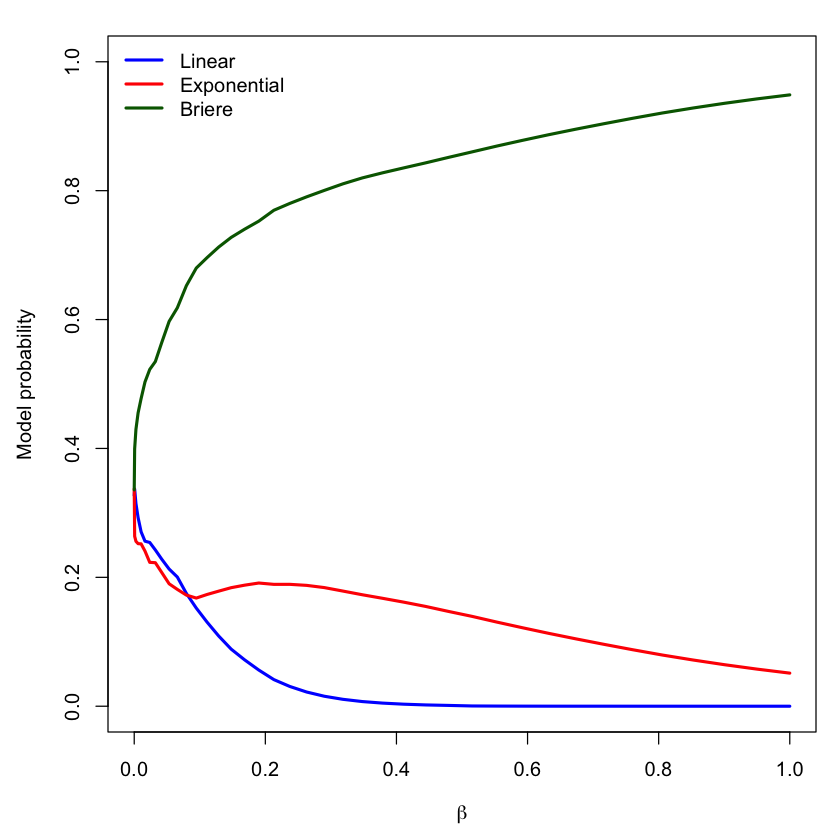

In [13]:
model_colours <- c(
  linear      = "blue",
  exponential = "red",
  briere      = "darkgreen"
)

model_probabilities <- as.matrix(
  smc_fit$model_history[, c("linear", "exponential", "briere")]
)

par(bg = "white", mar = c(4.5, 4.5, 1.5, 1))

matplot(x = smc_fit$model_history$temperature, y = model_probabilities,
  type = "l", lty = 1, lwd = 2.5, col = model_colours,
  ylim = c(0, 1), xlab = expression(beta), ylab = "Model probability")

legend("topleft",
  legend = c("Linear", "Exponential", "Briere"),
  col = model_colours, lty = 1, lwd = 2.5, bty = "n")

At the beginning, model and parameter moves tend to be accepted frequently because the target distribution remains close to the prior.

As $\beta$ approaches one, the observations impose stronger constraints. Proposals that move particles away from well-supported regions are then less likely to be accepted.

At the final stage, $\beta=1$, so the particles approximate $P(M,\theta_M\mid\delta)$.

The posterior probability of a model is obtained by integrating over all of its possible parameter configurations:

$
P(M\mid\delta) = \int P(M,\theta_M\mid\delta)\,d\theta_M.
$

In the particle approximation, this integral becomes a **sum of particle weights**.

In [14]:
data.frame(smc_fit$model_probability)

,smc_fit.model_probability
,<dbl>
linear,8.502610e-07
exponential,5.134537e-02
briere,9.486538e-01


This would mean that, among the three models considered and under the specified priors, the Brière model has the greatest posterior support.

It would not mean that the probability that the true relationship is Brière is $0.95$ in an unrestricted sense.

The result is conditional on:

* the observed data;
* the three candidate models;
* their parameter priors;
* the model prior;
* the assumed observation model.

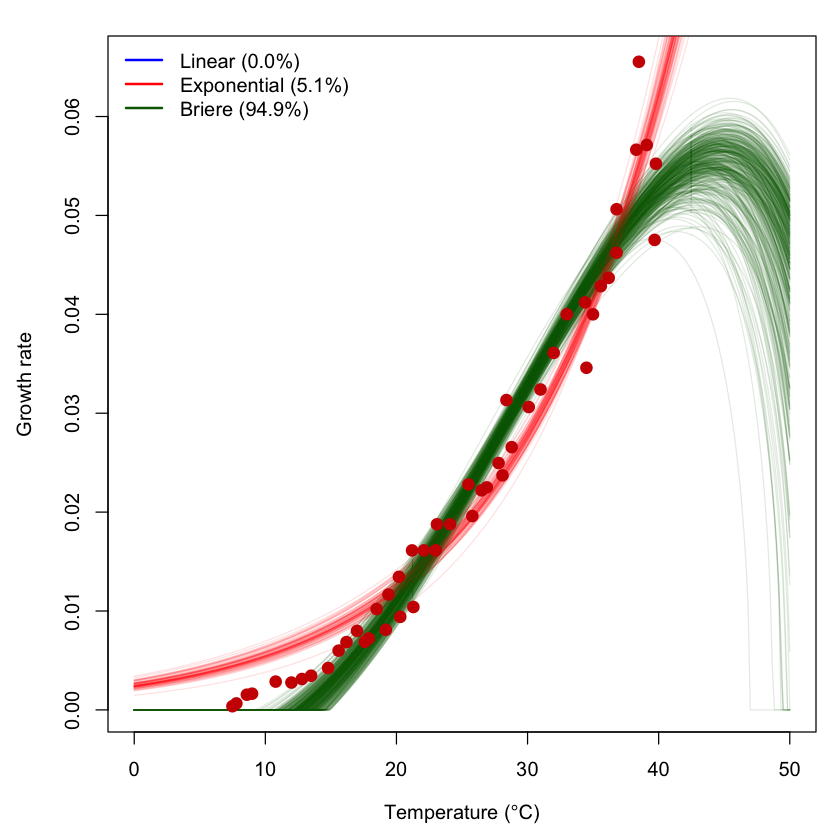

In [16]:
model_colours <- c(
  linear      = "blue",
  exponential = "red",
  briere      = "darkgreen"
)

T_grid <- seq(0, 50, length.out = 300)

particle_index <- sample(seq_len(nrow(smc_fit$particles)), size = min(500, nrow(smc_fit$particles)))

par(bg = "white", mar = c(4.5, 4.5, 1.5, 1))

plot(d2$T.C, d2$rate.per.minute,
     xlim = range(T_grid), type = "n", ylab = "Growth rate",
     xlab = expression("Temperature (" * degree * "C)"))

for (i in particle_index) {
  model_name <- smc_fit$particles$model[i]
  param <- c(
    pr_a = smc_fit$particles$pr_a[i],
    pr_b = smc_fit$particles$pr_b[i],
    pr_c = smc_fit$particles$pr_c[i]
  )

  expected <- models[[model_name]]$sim.mean(T_grid, param)

  lines(T_grid, expected,
        col = adjustcolor(
          model_colours[model_name],
          alpha.f = 0.12
        ),
        lwd = 1)
}

# Draw observations over the posterior curves
points(d2$T.C, d2$rate.per.minute,
       pch = 16, cex = 1.4, col = cols["d"])

model_probabilities <- smc_fit$model_probability

legend("topleft", 
       legend = sprintf("%s (%.1f%%)",
                        c("Linear", "Exponential", "Briere"),
                        100 * model_probabilities[c("linear", "exponential", "briere")]),
       col = model_colours, lty = 1, lwd = 2, bty = "n")

We do not necessarily need to select one model and discard the others.

Because the particles represent the joint posterior, we can average predictions over both model and parameter uncertainty.

Using the particles, this can be approximated by generating a prediction from every particle and averaging the results.

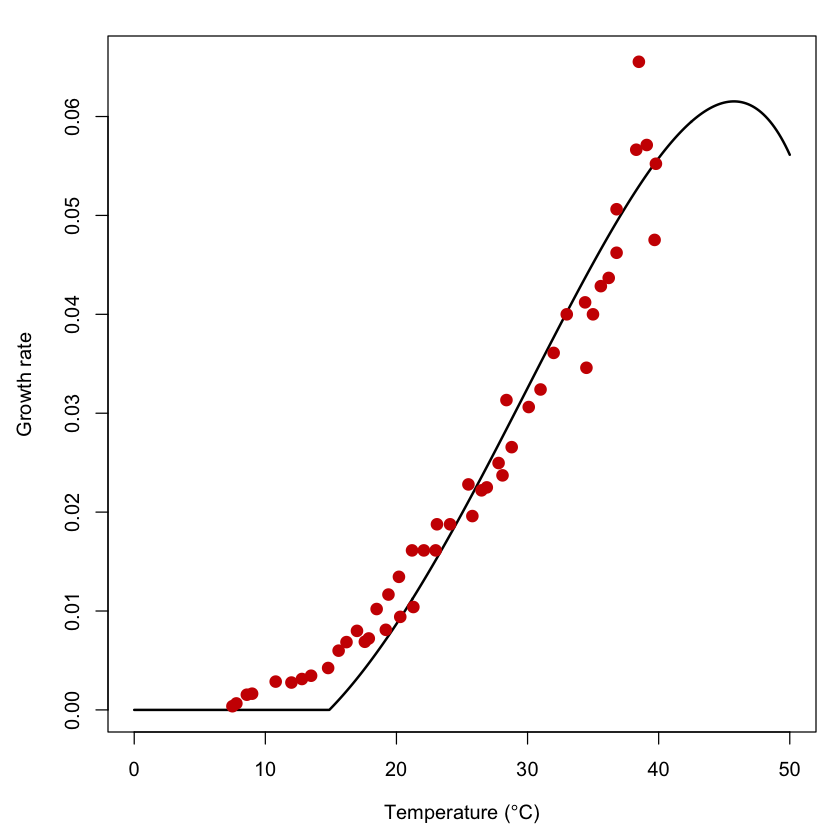

In [17]:
T_grid <- seq(0, 50, length.out = 300)

particle_index <- seq_len(nrow(smc_fit$particles))

expected_matrix <- matrix(
  NA_real_,
  nrow = length(particle_index),
  ncol = length(T_grid)
)

for (i in particle_index) {
  model_name <- smc_fit$particles$model[i]

  param <- unlist(smc_fit$particles[i, c("pr_a", "pr_b", "pr_c")], use.names = TRUE)

  # Remove parameters not used by the selected model
  param <- param[!is.na(param)]

  expected_matrix[i, ] <- models[[model_name]]$sim.mean(T_grid, param)
}

mean_expected <- colMeans(expected_matrix)

par(bg = "white", mar = c(4.5, 4.5, 1.5, 1))

plot(d2$T.C, d2$rate.per.minute,
     xlim = range(T_grid), type = "n", ylab = "Growth rate",
     xlab = expression("Temperature (" * degree * "C)"))

lines(T_grid, expected,
      lwd = 2)

# Draw observations over the posterior curves
points(d2$T.C, d2$rate.per.minute,
       pch = 16, cex = 1.4, col = cols["d"])




### Limitations of the basic model-move proposal

The model move in this implementation proposes new parameters directly from the prior. This is simple and ensures that the acceptance ratio is easy to calculate. However, it may become inefficient late in the SMC sequence.

When $\beta$ is close to one, posterior support may occupy only a small part of the prior parameter space. A newly proposed parameter configuration drawn from the prior will then usually have a poor likelihood and be rejected.

For more advanced implementations, see **Introducing Monte Carlo Methods with R** by Robert and Casella [<a href="https://link.springer.com/book/10.1007/978-1-4419-1576-4" target="_blank" rel="noopener noreferrer"><strong>link</strong></a>].